# Champo Carpet Customer Segmentation using Clustering

## Importing the libraries and data file

In [5]:
# import pandas, numpy, seaborn and library required to perform clustering - k-means, dbscan and hdbscan

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:
# Read champo_carpet.csv file and show head(5)

df_champo = pd.read_csv('champo_carpet.csv')
df_champo.head(5)


,CustomerCode,CountryName,QtyRequired,TotalArea,Amount,ITEM_NAME,QualityName,DesignName,ColorName,ShapeName,AreaFt,AreaMtr
0,H-1,USA,6,128.25,769.5,HAND TUFTED,TUFTED 30C HARD TWIST,OLD LONDON [3715],GREEN/IVORY,REC,128.25,11.5425
1,H-1,USA,6,117.00,702.0,HAND TUFTED,TUFTED 60C,DUDLEY [9012],BEIGE,REC,117.00,10.5300
2,H-1,USA,7,88.00,616.0,HAND TUFTED,TUFTED 60C,WEMBLY [CC-206],BEIGE/SAGE,REC,88.00,7.9200
3,H-1,USA,7,88.00,616.0,HAND TUFTED,TUFTED 60C,SYMPHONY [8900],CHARCOAL,REC,88.00,7.9200
4,H-1,USA,5,117.00,585.0,HAND TUFTED,TUFTED 60C,DUDLEY [9012],NAVY/BEIGE,REC,117.00,10.5300


In [ ]:
# Describe df_champo and run info as well to check the missing values

df_champo.info()
df_champo.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13135 entries, 0 to 13134
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CustomerCode  13135 non-null  object 
 1   CountryName   13135 non-null  object 
 2   QtyRequired   13135 non-null  int64  
 3   TotalArea     13135 non-null  float64
 4   Amount        13135 non-null  float64
 5   ITEM_NAME     13135 non-null  object 
 6   QualityName   13135 non-null  object 
 7   DesignName    13135 non-null  object 
 8   ColorName     13135 non-null  object 
 9   ShapeName     13135 non-null  object 
 10  AreaFt        13135 non-null  float64
 11  AreaMtr       13135 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.2+ MB


,QtyRequired,TotalArea,Amount,AreaFt,AreaMtr
count,13135.000000,13135.000000,13135.000000,13135.000000,13135.000000
mean,44.460601,44.731370,2392.040164,54.622369,4.951740
std,228.749535,50.099597,16832.091080,49.072767,4.455933
min,1.000000,0.040000,0.000000,0.444400,0.040000
25%,3.000000,5.800000,163.200000,15.000000,1.350000
50%,8.000000,24.000000,590.625000,40.000000,3.600000
75%,20.000000,80.000000,1540.000000,80.000000,7.200000
max,6400.000000,1024.000000,599719.680000,645.722200,60.000000


## Check correlation between TotalArea and AreaFt

In [ ]:
# Since TotalArea and AreaFt looks similar with eye-ball check - but to check statistically how similar they are, let us run correlation test on these columns

# Calculate the correlation between 'TotalArea' and 'AreaFt'
correlation = df_champo['TotalArea'].corr(df_champo['AreaFt'])

print(f"Correlation between TotalArea and AreaFt: {correlation}")


Correlation between TotalArea and AreaFt: 0.8286136425083274


- The correlation is very high, hence we can choose to keep only one of them

## Feature Engineering using Random Forest

In [ ]:
# Assuming Amount is the Y, let us run the feature importance test using random forest to do feature selection, also we can drop areaft and areamtr because they are the same as total area

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Drop 'AreaFt' and 'AreaMtr' columns
df_champo = df_champo.drop(['AreaFt', 'AreaMtr'], axis=1)

# Define features (X) and target (y)
X = df_champo.drop('Amount', axis=1)
y = df_champo['Amount']

# Convert non-numeric columns to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_

# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})

# Sort features by importance in descending order
feature_importances = feature_importances.sort_values('importance', ascending=False)

# Print or visualize the feature importances
feature_importances


,feature,importance
0,QtyRequired,0.568944
1,TotalArea,0.110009
472,DesignName_9634 HT GREY (3940),0.043165
461,DesignName_9604 HT PURPLE (2836),0.035105
44,CustomerCode_TGT,0.019374
...,...,...
397,DesignName_10658,0.000000
272,DesignName_10020,0.000000
1612,ColorName_RAMA,0.000000
1613,ColorName_RAMA WITH WHITE,0.000000


from matplotlib import pyplot as plt
feature_importances['importance'].plot(kind='hist', bins=20, title='importance')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
feature_importances['importance'].plot(kind='line', figsize=(8, 4), title='importance')
plt.gca().spines[['top', 'right']].set_visible(False)

### Add Amount/TotalArea as PricePerFt

In [ ]:
# Let us add Amount/TotalArea as PricePerFt column for extra feature

# Calculate 'PricePerFt'
df_champo['PricePerFt'] = df_champo['Amount'] / df_champo['TotalArea']


## Plotting Elbow Curve without PricePerFt column

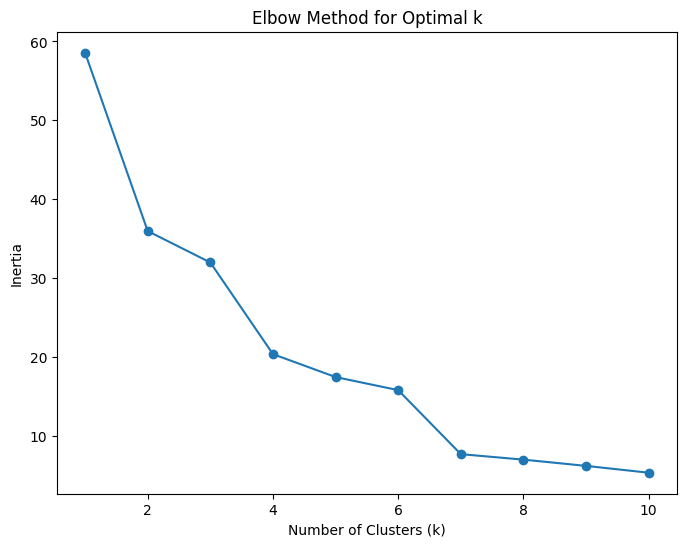

In [ ]:
# Now, considering Amount, QtyRequired, TotalArea columns - let us performing elbow test by first scaling these columns and then run the clustering using K-means

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Select features for clustering
features_for_clustering = ['Amount', 'QtyRequired', 'TotalArea']
df_cluster = df_champo[features_for_clustering]

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
df_cluster_scaled = scaler.fit_transform(df_cluster)

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)  # Test k values from 1 to 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


## Plotting Elbow Curve with PricePerFt column

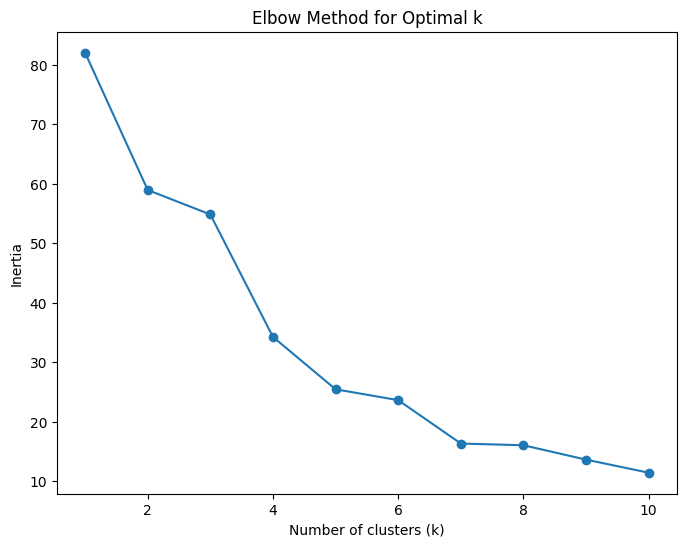

In [ ]:
# Now, considering Amount, QtyRequired, TotalArea columns - let us performing elbow test by first scaling these columns and then run the clustering using K-means

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Select features for clustering
features_for_clustering = ['Amount', 'QtyRequired', 'TotalArea','PricePerFt']
df_cluster = df_champo[features_for_clustering]

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
df_cluster_scaled = scaler.fit_transform(df_cluster)

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)  # Test k values from 1 to 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


## Building K-Means cluster

In [ ]:
# Lets run k means on scaled data df_cluster_scaled for cluster list from 3 to 10 and record silhoutte score - print cluster and respective sillhoutte score first and then give best cluster size and silhoutte score

from sklearn.metrics import silhouette_score

# Assuming df_cluster_scaled is already defined as in the provided code

best_cluster_size = 0
best_silhouette_score = -1  # Initialize with a very low value

for n_clusters in range(3, 11):
    kmeans = KMeans(n_clusters=n_clusters, init="k-means++", n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_cluster_scaled)
    silhouette_avg = silhouette_score(df_cluster_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")

    if silhouette_avg > best_silhouette_score:
        best_silhouette_score = silhouette_avg
        best_cluster_size = n_clusters

print(f"\nBest cluster size: {best_cluster_size}")
print(f"Best silhouette score: {best_silhouette_score}")


For n_clusters = 3, the average silhouette_score is : 0.6087948920887507
For n_clusters = 4, the average silhouette_score is : 0.6099482317479873
For n_clusters = 5, the average silhouette_score is : 0.6142108888332701
For n_clusters = 6, the average silhouette_score is : 0.5713049489873362
For n_clusters = 7, the average silhouette_score is : 0.5936091679429696
For n_clusters = 8, the average silhouette_score is : 0.513440460052678
For n_clusters = 9, the average silhouette_score is : 0.48519767375039813
For n_clusters = 10, the average silhouette_score is : 0.5278916344781784

Best cluster size: 5
Best silhouette score: 0.6142108888332701


In [ ]:
# Now, let us run k-means clustering on the scaled variables - ['Amount', 'QtyRequired', 'TotalArea','PricePerFt'] by keeping cluster as 5 and generate cluster column in the dataframe itself

# Perform K-means clustering with k=5
kmeans = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
df_champo['cluster'] = kmeans.fit_predict(df_cluster_scaled)


In [ ]:
# Count customers in each cluster
cluster_counts = df_champo['cluster'].value_counts()
cluster_counts


,count
cluster,
0,8906
1,4045
2,127
3,29
4,28


### Cluster / Segment analysis

In [ ]:
# Key numerical features to analyze
features = ["Amount", "TotalArea", "QtyRequired", "PricePerFt"]

# Compute cluster-wise statistics
cluster_summary = df_champo.groupby("cluster")[features].agg(["mean", "median", "min", "max", "count"])

# Business Inferences based on patterns
business_inferences = {}

for cluster, group in df_champo.groupby("cluster"):
    avg_amount = group["Amount"].mean()
    avg_area = group["TotalArea"].mean()
    avg_qty = group["QtyRequired"].mean()
    avg_price_per_ft = group["PricePerFt"].mean()
    total_customers = len(group)

    if avg_qty > df_champo["QtyRequired"].quantile(0.75) and avg_area > df_champo["TotalArea"].quantile(0.75):
      business_inferences[cluster] = "Bulk buyers purchasing high volumes. Offer bulk discounts and loyalty incentives."

    elif avg_price_per_ft > df_champo["PricePerFt"].quantile(0.75):  # High-value buyers
        business_inferences[cluster] = "Premium buyers purchasing high-quality carpets. Offer exclusive high-end collections."

    elif total_customers < 50:  # Small niche clusters
        business_inferences[cluster] = "Special customers with unique order patterns. Provide personalized services."

    elif avg_amount < df_champo["Amount"].quantile(0.25):  # Low-value segment
        business_inferences[cluster] = "Low-spending customers. Target with budget-friendly collections."

    else:
        business_inferences[cluster] = "General buyers. Optimize pricing and sample selection to improve conversions."

# Display results
print("\ncluster-Wise Statistics:\n", cluster_summary)
print("\nBusiness Inferences:\n")
for cluster, inference in business_inferences.items():
    print(f"cluster {cluster}: {inference}")



cluster-Wise Statistics:
                 Amount                                           TotalArea  \
                  mean      median        min        max count        mean   
cluster                                                                      
0          1274.450449     405.000       0.00   67175.50  8906   16.613894   
1          2263.114092     932.800       0.00  152564.30  4045  107.915920   
2          5257.513062    2636.445     501.75   30498.00   127    0.971274   
3        321535.657931  343504.800  167433.70  599719.68    29   89.655172   
4         32952.039643    6320.000       0.00  238579.41    28   12.141368   

                                             QtyRequired                      \
           median      min        max count         mean  median   min   max   
cluster                                                                        
0          8.4375   0.0400    60.1250  8906    40.095217    10.0     1  1800   
1        108.0000  62.5000  

#### Box-plot for spread of the numerical attributes

<ipython-input-21-23efb597942a>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_champo, palette="viridis")


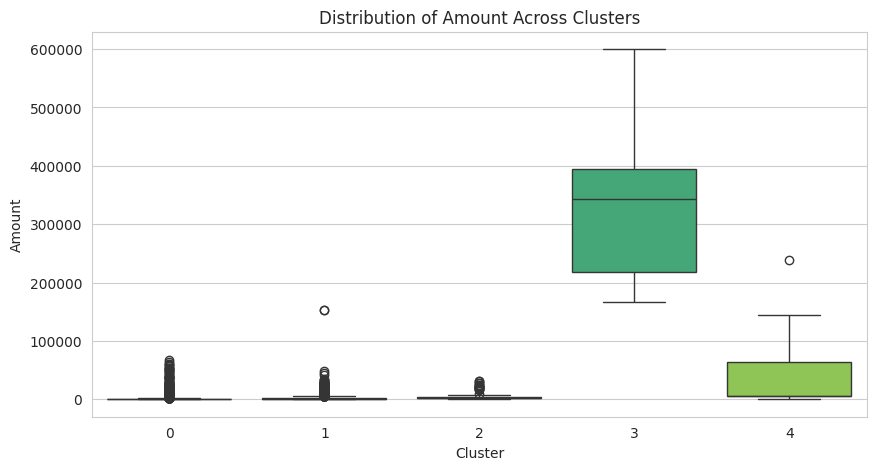

<ipython-input-21-23efb597942a>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_champo, palette="viridis")


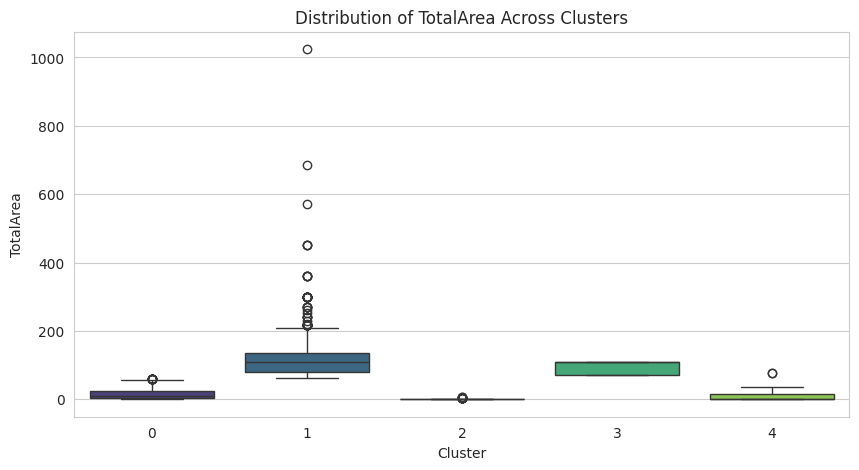

<ipython-input-21-23efb597942a>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_champo, palette="viridis")


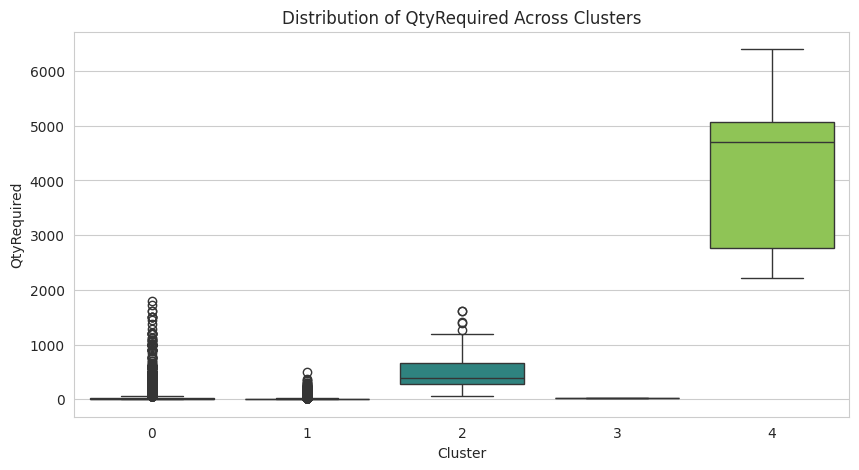

<ipython-input-21-23efb597942a>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_champo, palette="viridis")


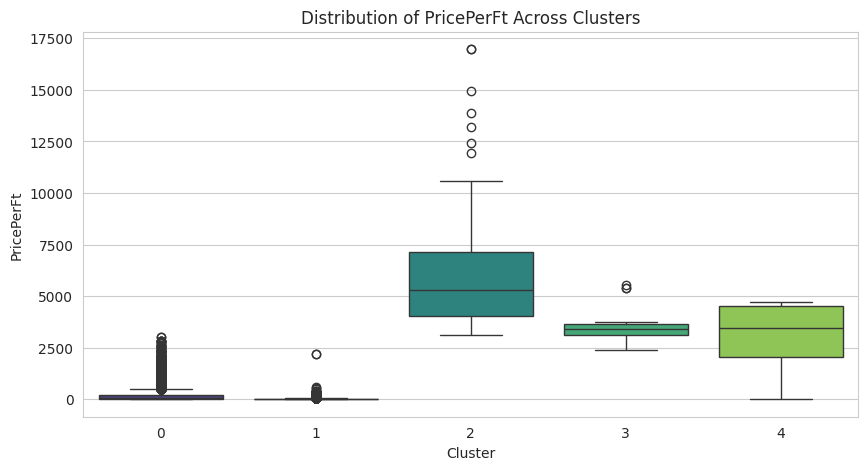

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting plot style
sns.set_style("whitegrid")

# List of numerical features used for clustering
features = ["Amount", "TotalArea", "QtyRequired", "PricePerFt"]

# Creating boxplots for each feature across clusters
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="cluster", y=feature, data=df_champo, palette="viridis")
    plt.title(f"Distribution of {feature} Across Clusters")
    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.show()


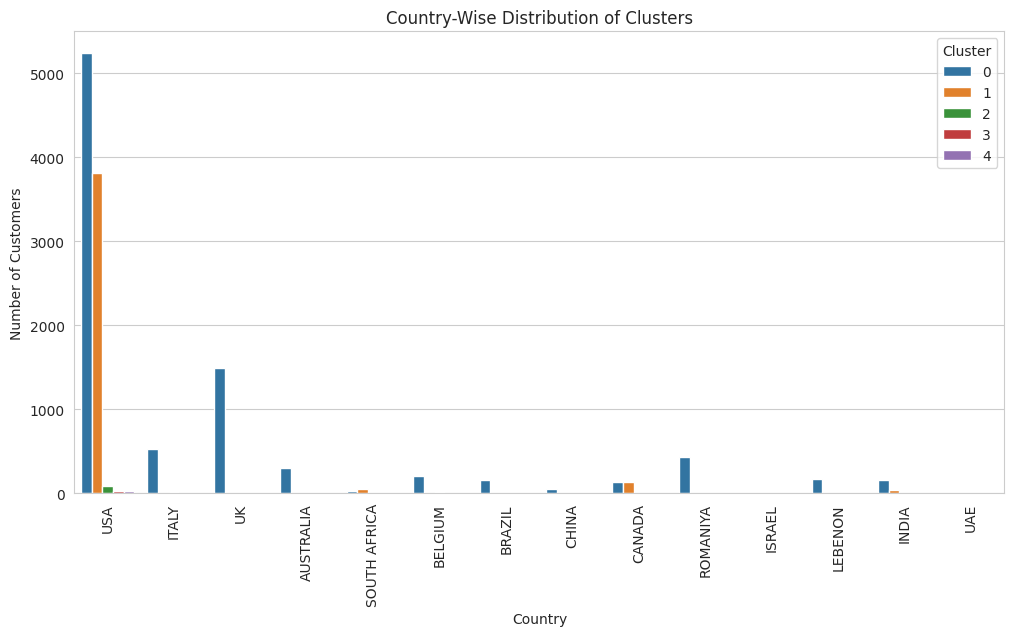

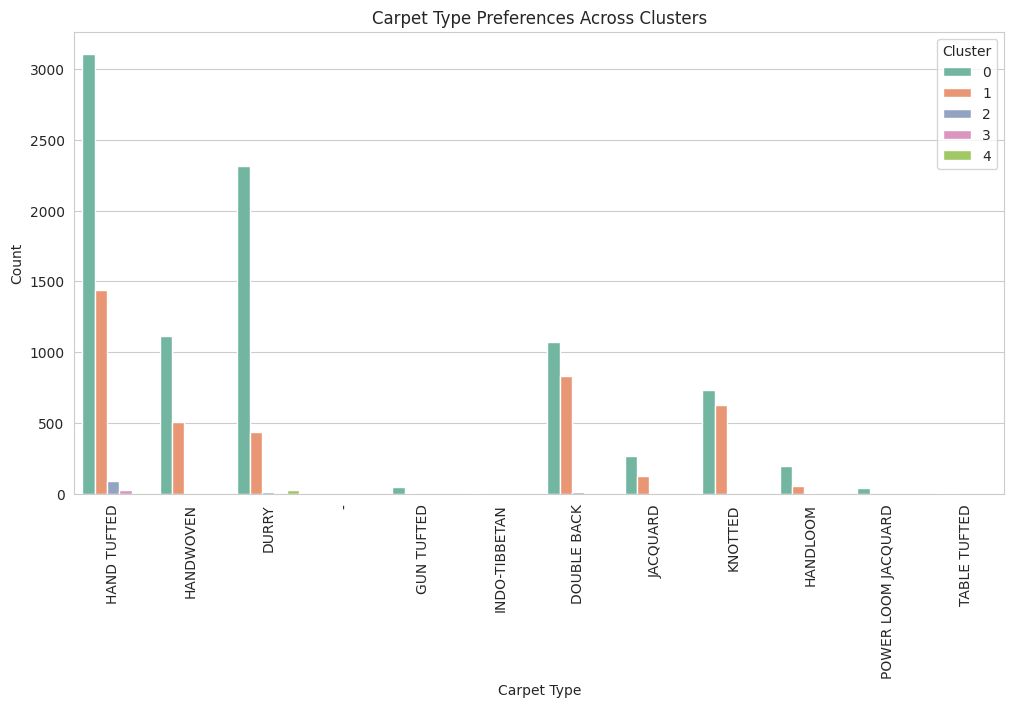

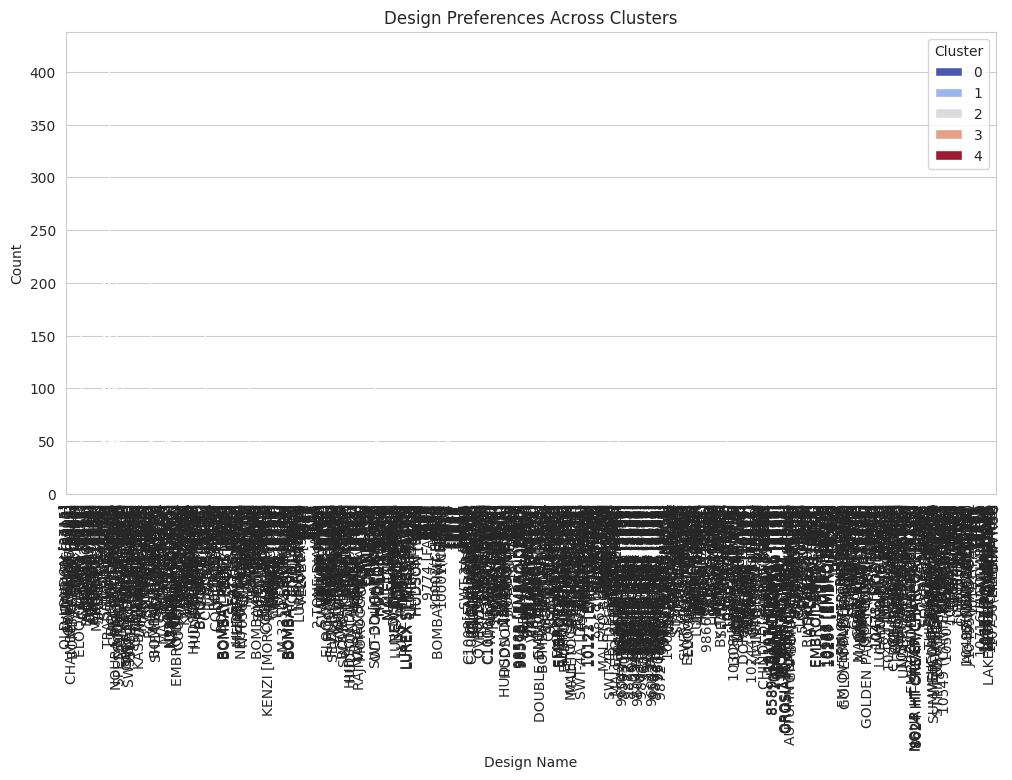

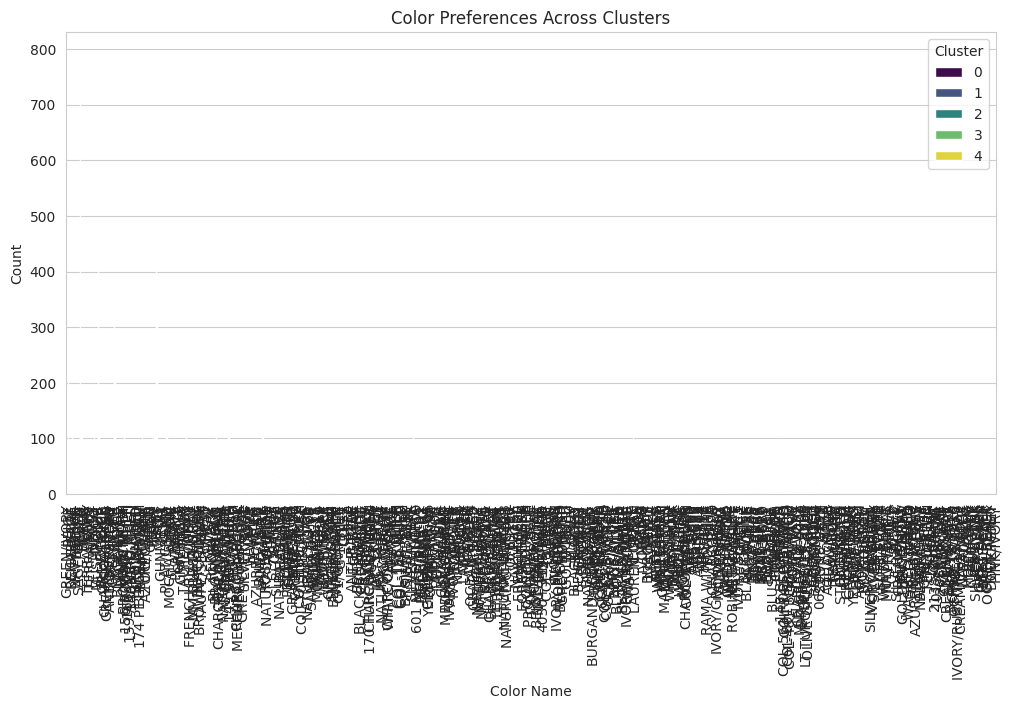

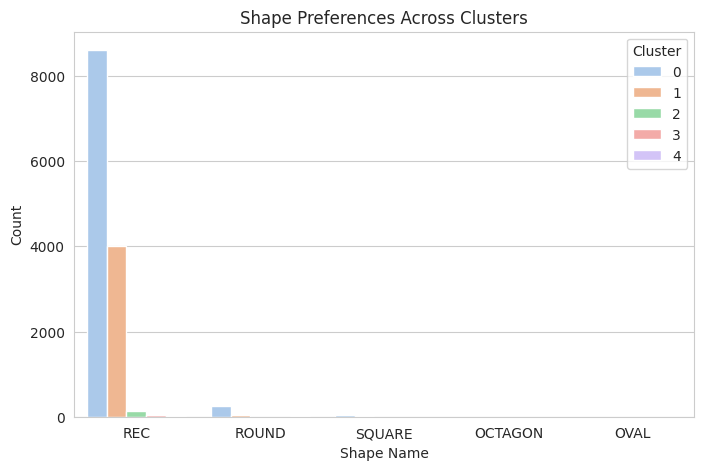

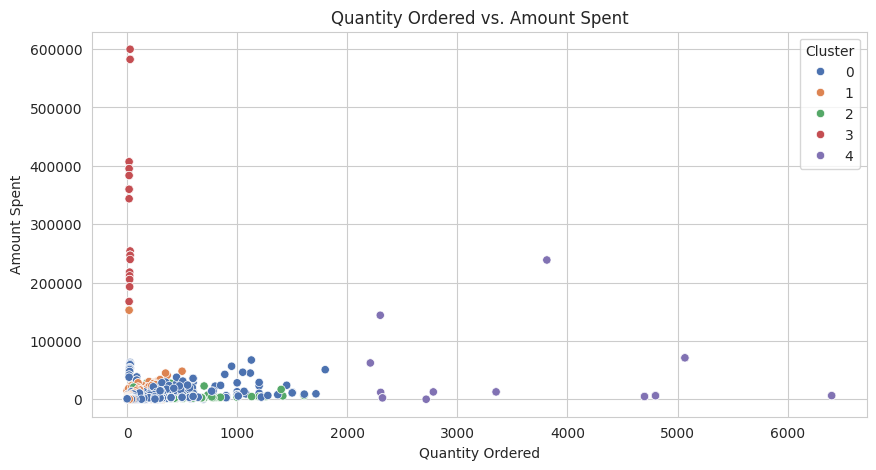

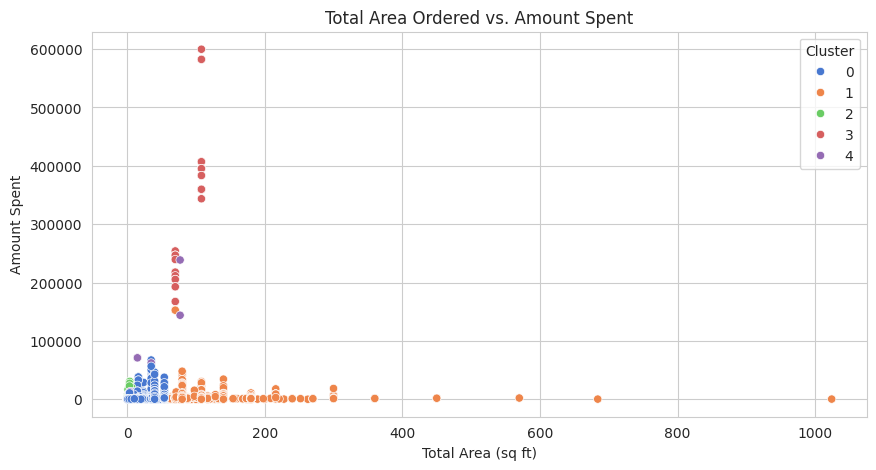

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Country-Wise Customer Segmentation
plt.figure(figsize=(12, 6))
sns.countplot(x="CountryName", hue="cluster", data=df_champo, palette="tab10")
plt.xticks(rotation=90)
plt.title("Country-Wise Distribution of Clusters")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.legend(title="Cluster")
plt.show()

# Carpet Type Preferences by Cluster
plt.figure(figsize=(12, 6))
sns.countplot(x="ITEM_NAME", hue="cluster", data=df_champo, palette="Set2")
plt.xticks(rotation=90)
plt.title("Carpet Type Preferences Across Clusters")
plt.xlabel("Carpet Type")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.show()

# Design & Color Preferences Across Clusters
plt.figure(figsize=(12, 6))
sns.countplot(x="DesignName", hue="cluster", data=df_champo, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Design Preferences Across Clusters")
plt.xlabel("Design Name")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x="ColorName", hue="cluster", data=df_champo, palette="viridis")
plt.xticks(rotation=90)
plt.title("Color Preferences Across Clusters")
plt.xlabel("Color Name")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.show()

# Shape Preferences in Different Clusters
plt.figure(figsize=(8, 5))
sns.countplot(x="ShapeName", hue="cluster", data=df_champo, palette="pastel")
plt.title("Shape Preferences Across Clusters")
plt.xlabel("Shape Name")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.show()

# Order Size vs. Amount Correlation Per Cluster (Scatter Plots)
plt.figure(figsize=(10, 5))
sns.scatterplot(x="QtyRequired", y="Amount", hue="cluster", data=df_champo, palette="deep")
plt.title("Quantity Ordered vs. Amount Spent")
plt.xlabel("Quantity Ordered")
plt.ylabel("Amount Spent")
plt.legend(title="Cluster")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x="TotalArea", y="Amount", hue="cluster", data=df_champo, palette="muted")
plt.title("Total Area Ordered vs. Amount Spent")
plt.xlabel("Total Area (sq ft)")
plt.ylabel("Amount Spent")
plt.legend(title="Cluster")
plt.show()


#### Country wise study of the clusters

<Figure size 1400x700 with 0 Axes>

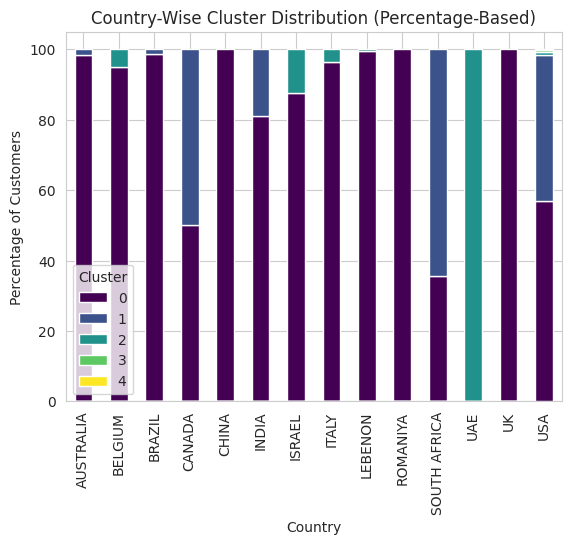

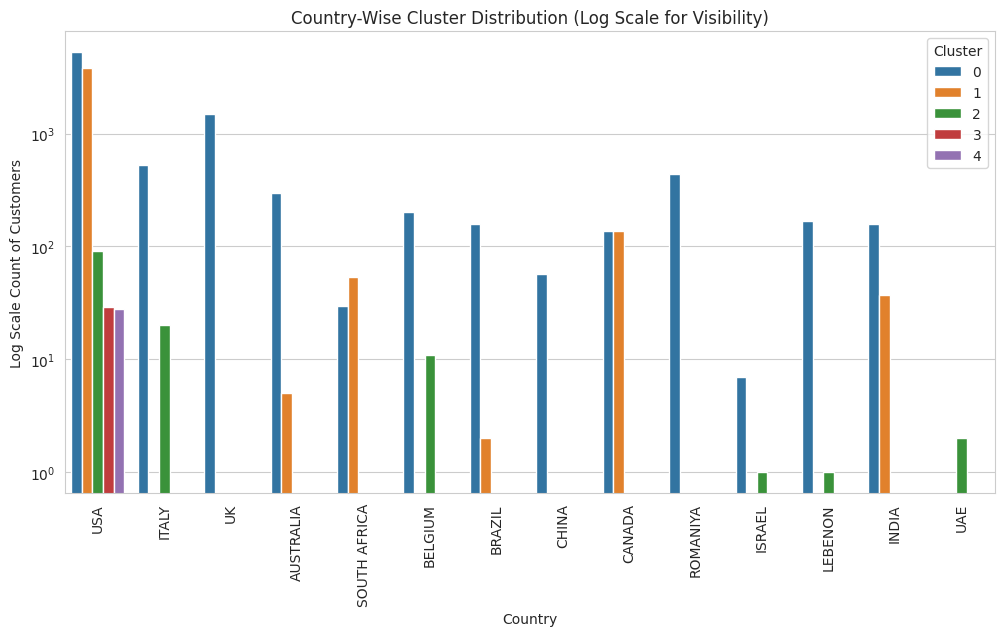

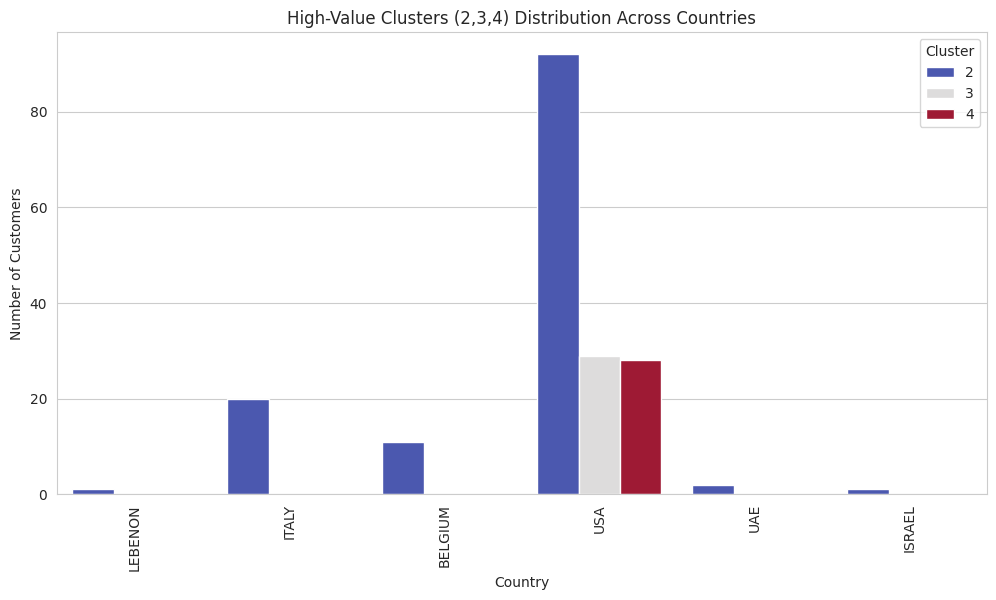

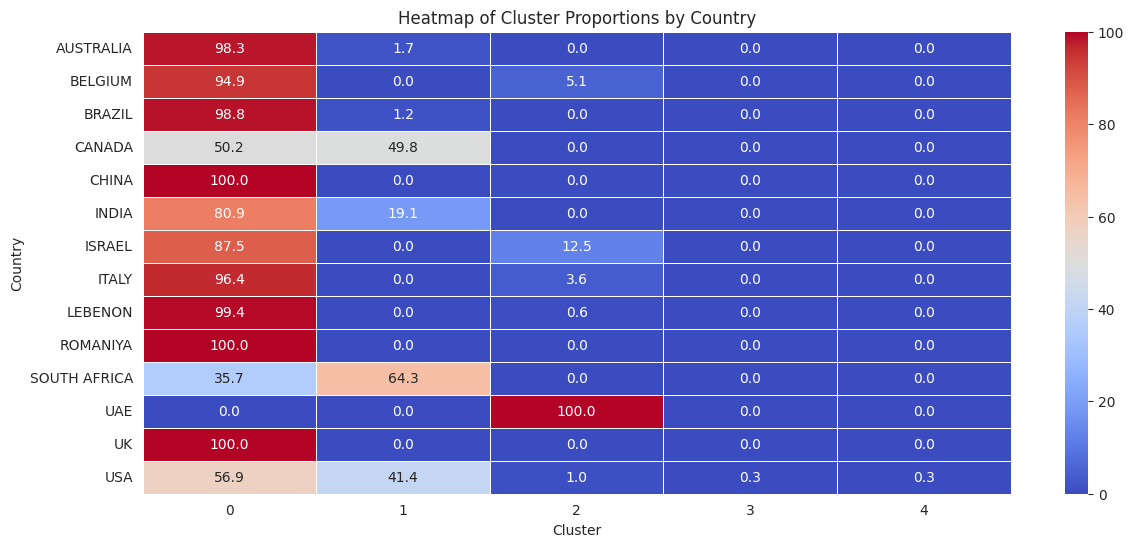

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Normalize Data for Percentage-Based Stacked Bar Chart
df_country_cluster = df_champo.groupby(["CountryName", "cluster"]).size().unstack().fillna(0)
df_country_cluster_percentage = df_country_cluster.div(df_country_cluster.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))
df_country_cluster_percentage.plot(kind="bar", stacked=True, colormap="viridis")
plt.title("Country-Wise Cluster Distribution (Percentage-Based)")
plt.xlabel("Country")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=90)
plt.legend(title="Cluster")
plt.show()

# Log Scale to Highlight Small Clusters
plt.figure(figsize=(12, 6))
sns.countplot(x="CountryName", hue="cluster", data=df_champo, palette="tab10")
plt.yscale("log")  # Apply log scale
plt.xticks(rotation=90)
plt.title("Country-Wise Cluster Distribution (Log Scale for Visibility)")
plt.xlabel("Country")
plt.ylabel("Log Scale Count of Customers")
plt.legend(title="Cluster")
plt.show()

# High-Value Clusters Only (2,3,4)
df_high_value_clusters = df_champo[df_champo["cluster"].isin([2, 3, 4])]

plt.figure(figsize=(12, 6))
sns.countplot(x="CountryName", hue="cluster", data=df_high_value_clusters, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("High-Value Clusters (2,3,4) Distribution Across Countries")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.legend(title="Cluster")
plt.show()

# Heatmap of Cluster Proportions Per Country
plt.figure(figsize=(14, 6))
sns.heatmap(df_country_cluster_percentage, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5)
plt.title("Heatmap of Cluster Proportions by Country")
plt.xlabel("Cluster")
plt.ylabel("Country")
plt.show()


#### Carpet Type wise study of the clusters

<Figure size 1400x700 with 0 Axes>

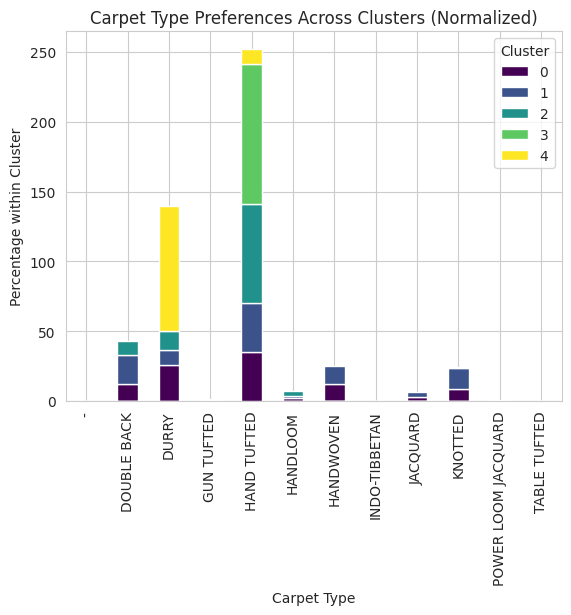

In [ ]:
# Group data to count occurrences of each carpet type within each cluster
df_carpet_cluster = df_champo.groupby(["ITEM_NAME", "cluster"]).size().unstack().fillna(0)

# Convert absolute counts to percentages per cluster
df_carpet_cluster_percentage = df_carpet_cluster.div(df_carpet_cluster.sum(axis=0), axis=1) * 100

# Plot normalized stacked bar chart
plt.figure(figsize=(14, 7))
df_carpet_cluster_percentage.plot(kind="bar", stacked=True, colormap="viridis")
plt.title("Carpet Type Preferences Across Clusters (Normalized)")
plt.xlabel("Carpet Type")
plt.ylabel("Percentage within Cluster")
plt.xticks(rotation=90)
plt.legend(title="Cluster")
plt.show()


# Building DBScan to check if we get better silhoutte score

In [ ]:
# Now lets run DB scan on same scalled data by running range of eps and as well as min_samples to get best cluster size and silhoutte score with min_samples = range(6,20) ]
# eps = np.arange(0.01,0.2, 0.05)

import numpy as np
# Assuming df_cluster_scaled is already defined as in the provided code
from sklearn.metrics import silhouette_score

best_eps = 0
best_min_samples = 0
best_silhouette_score = -1

eps_values = np.arange(0.02, 0.2, 0.04)
min_samples_range = range(6, 10)

for eps in eps_values:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = dbscan.fit_predict(df_cluster_scaled)

        # Check if there's more than one cluster
        if len(set(cluster_labels)) > 1 :
          silhouette_avg = silhouette_score(df_cluster_scaled, cluster_labels)
          print(f"For eps = {eps}, min_samples = {min_samples}, the average silhouette_score is : {silhouette_avg}")

          if silhouette_avg > best_silhouette_score:
              best_silhouette_score = silhouette_avg
              best_eps = eps
              best_min_samples = min_samples

print(f"\nBest eps: {best_eps}")
print(f"Best min_samples: {best_min_samples}")
print(f"Best silhouette score: {best_silhouette_score}")


For eps = 0.02, min_samples = 6, the average silhouette_score is : 0.516808268394935
For eps = 0.02, min_samples = 7, the average silhouette_score is : 0.5304673698492561
For eps = 0.02, min_samples = 8, the average silhouette_score is : 0.5162293955798374
For eps = 0.02, min_samples = 9, the average silhouette_score is : 0.5096907025606654
For eps = 0.06, min_samples = 6, the average silhouette_score is : 0.8316916504236586
For eps = 0.06, min_samples = 7, the average silhouette_score is : 0.8373861949135188
For eps = 0.06, min_samples = 8, the average silhouette_score is : 0.8372688475101617
For eps = 0.06, min_samples = 9, the average silhouette_score is : 0.8349763433406255
For eps = 0.09999999999999999, min_samples = 6, the average silhouette_score is : 0.8312562483341197
For eps = 0.09999999999999999, min_samples = 7, the average silhouette_score is : 0.8312562483341197
For eps = 0.09999999999999999, min_samples = 8, the average silhouette_score is : 0.8314684701466164
For eps = 

In [ ]:
# Build dbscan with only best eps value and best min_samples valu and check the number of cluster - assign -1 to unclustered group

# Perform DBSCAN clustering with the best hyperparameters
dbscan = DBSCAN(eps=0.06, min_samples=7)
df_champo['cluster_dbscan'] = dbscan.fit_predict(df_cluster_scaled)

# Count the number of clusters, assigning -1 to unclustered points
num_clusters = len(set(df_champo['cluster_dbscan'])) - (1 if -1 in df_champo['cluster_dbscan'] else 0)
print(f"Number of clusters found by DBSCAN: {num_clusters}")


Number of clusters found by DBSCAN: 5


In [ ]:
# Check the value count of each cluster from dbscan

# Count the number of data points in each cluster
cluster_counts_dbscan = df_champo['cluster_dbscan'].value_counts()
cluster_counts_dbscan


,count
cluster_dbscan,
0,13061
-1,39
2,14
1,12
3,9


#### No better sillhoutte score than K-Means hence sticking to the previous cluster strategy

# Building HDBScan to check if we get better silhoutte score

In [ ]:
# Run hdbscan with 5 iterations of the hyperparemeters and record the best silhoutte score and number of clusters recommended. avoid and handle warnings

import warnings
warnings.filterwarnings("ignore")

min_samples_range = range(6,20)
min_cluster_sizes = [5, 10, 20]

best_min_samples = 0
best_min_cluster_size = 0
best_silhouette_score = -1

for min_samples in min_samples_range:
    for min_cluster_size in min_cluster_sizes:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        cluster_labels = clusterer.fit_predict(df_cluster_scaled)

        # Check if there's more than one cluster
        if len(set(cluster_labels)) > 1:
            try:
                silhouette_avg = silhouette_score(df_cluster_scaled, cluster_labels)
                print(f"For min_samples = {min_samples}, min_cluster_size = {min_cluster_size}, the average silhouette_score is : {silhouette_avg}")

                if silhouette_avg > best_silhouette_score:
                    best_silhouette_score = silhouette_avg
                    best_min_samples = min_samples
                    best_min_cluster_size = min_cluster_size
            except ValueError:
                print(f"Silhouette score calculation failed for min_samples = {min_samples}, min_cluster_size = {min_cluster_size}.")
                pass # Skip to the next iteration


print(f"\nBest min_samples: {best_min_samples}")
print(f"Best min_cluster_size: {best_min_cluster_size}")
print(f"Best silhouette score: {best_silhouette_score}")


For min_samples = 6, min_cluster_size = 5, the average silhouette_score is : 0.27379492405416966
For min_samples = 6, min_cluster_size = 10, the average silhouette_score is : 0.17150783982502218
For min_samples = 6, min_cluster_size = 20, the average silhouette_score is : -0.022615241972220135
For min_samples = 7, min_cluster_size = 5, the average silhouette_score is : 0.22199774850664317
For min_samples = 7, min_cluster_size = 10, the average silhouette_score is : 0.14446401775239212
For min_samples = 7, min_cluster_size = 20, the average silhouette_score is : -0.04351637028095915
For min_samples = 8, min_cluster_size = 5, the average silhouette_score is : 0.1729578547305084
For min_samples = 8, min_cluster_size = 10, the average silhouette_score is : 0.10638741853514372
For min_samples = 8, min_cluster_size = 20, the average silhouette_score is : -0.06483525459622724
For min_samples = 9, min_cluster_size = 5, the average silhouette_score is : 0.12223977034275008
For min_samples = 9, 

#### No better sillhoutte score than K-Means hence sticking to the previous cluster strategy

### By RFM

In [2]:
#read csv called champo_raw.csv in df_raw

import pandas as pd

df_raw = pd.read_csv('champo_raw.csv')


In [ ]:
df_raw.head(5)

,OrderType,OrderCategory,CustomerCode,CountryName,CustomerOrderNo,Custorderdate,UnitName,QtyRequired,TotalArea,Amount,ITEM_NAME,QualityName,DesignName,ColorName,ShapeName,AreaFt
0,Area Wise,Order,H-1,USA,1873354,1/16/17 0:00,Ft,2,6.00,12.00,HAND TUFTED,TUFTED 30C HARD TWIST,OLD LONDON [3715],BEIGE,REC,6.00
1,Area Wise,Order,H-1,USA,1873354,1/16/17 0:00,Ft,2,9.00,18.00,HAND TUFTED,TUFTED 30C HARD TWIST,OLD LONDON [3715],BEIGE,REC,9.00
2,Area Wise,Order,H-1,USA,1873354,1/16/17 0:00,Ft,2,54.00,108.00,HAND TUFTED,TUFTED 30C HARD TWIST,OLD LONDON [3715],BEIGE,REC,54.00
3,Area Wise,Order,H-1,USA,1918436,2/1/17 0:00,Ft,5,54.00,270.00,HAND TUFTED,TUFTED 30C HARD TWIST,OLD LONDON [3715],BEIGE,REC,54.00
4,Area Wise,Order,H-1,USA,1873354,1/16/17 0:00,Ft,5,71.25,356.25,HAND TUFTED,TUFTED 30C HARD TWIST,OLD LONDON [3715],BEIGE,REC,71.25


In [3]:
# Want to create rfm columns from the DF - using Custorderdate, Amount

df_raw['Custorderdate'] = pd.to_datetime(df_raw['Custorderdate'])

# Calculate Recency
snapshot_date = df_raw['Custorderdate'].max() + pd.Timedelta(days=1)  # Add one day to avoid zero recency
df_raw['Recency'] = (snapshot_date - df_raw['Custorderdate']).dt.days

# Calculate Frequency
customer_frequency = df_raw.groupby('CustomerCode')['Custorderdate'].count().reset_index()
customer_frequency.rename(columns={'Custorderdate': 'Frequency'}, inplace=True)
df_raw = pd.merge(df_raw, customer_frequency, on='CustomerCode', how='left')


# Calculate Monetary Value
customer_monetary_value = df_raw.groupby('CustomerCode')['Amount'].sum().reset_index()
customer_monetary_value.rename(columns={'Amount': 'MonetaryValue'}, inplace=True)
df_raw = pd.merge(df_raw, customer_monetary_value, on='CustomerCode', how='left')

# Display the updated DataFrame with RFM columns
print(df_raw[['CustomerCode', 'Custorderdate', 'Amount', 'Recency', 'Frequency', 'MonetaryValue']].head())


  CustomerCode Custorderdate  Amount  Recency  Frequency  MonetaryValue
0          H-1    2017-01-16   12.00     1125        193      65383.795
1          H-1    2017-01-16   18.00     1125        193      65383.795
2          H-1    2017-01-16  108.00     1125        193      65383.795
3          H-1    2017-02-01  270.00     1109        193      65383.795
4          H-1    2017-01-16  356.25     1125        193      65383.795


<ipython-input-3-726c27986d35>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['Custorderdate'] = pd.to_datetime(df_raw['Custorderdate'])


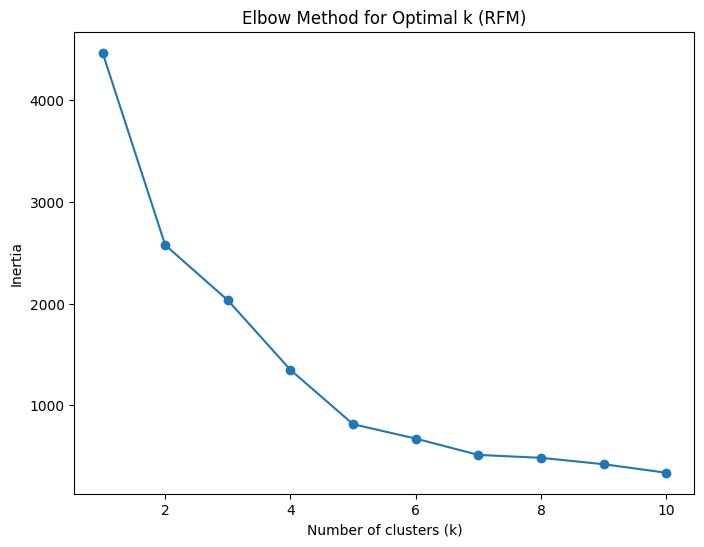

In [6]:
# Now let us plot elbow curve according to rfm columns

import matplotlib.pyplot as plt
# Assuming df_raw is already created with RFM columns as in the previous code

# Select features for clustering
rfm_features = ['Recency', 'Frequency', 'MonetaryValue']
df_rfm = df_raw[rfm_features]

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
df_rfm_scaled = scaler.fit_transform(df_rfm)

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)  # Test k values from 1 to 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k (RFM)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


In [7]:
# Let us create 5 clusters like this but by rfm columns in df_rfm_scaled

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

best_cluster_size = 0
best_silhouette_score = -1  # Initialize with a very low value

for n_clusters in range(3, 11):
    kmeans = KMeans(n_clusters=n_clusters, init="k-means++", n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_rfm_scaled)
    silhouette_avg = silhouette_score(df_rfm_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")
    if silhouette_avg > best_silhouette_score:
        best_silhouette_score = silhouette_avg
        best_cluster_size = n_clusters

print(f"\nBest cluster size: {best_cluster_size}")
print(f"Best silhouette score: {best_silhouette_score}")

# Perform K-means clustering with the best cluster size
kmeans = KMeans(n_clusters=best_cluster_size, init="k-means++", n_init=10, random_state=42)
df_raw['cluster_rfm'] = kmeans.fit_predict(df_rfm_scaled)

# Count customers in each cluster
cluster_counts = df_raw['cluster_rfm'].value_counts()
cluster_counts


For n_clusters = 3, the average silhouette_score is : 0.4371849330443122
For n_clusters = 4, the average silhouette_score is : 0.48207667632776663
For n_clusters = 5, the average silhouette_score is : 0.49373539492793933
For n_clusters = 6, the average silhouette_score is : 0.4698741999663412
For n_clusters = 7, the average silhouette_score is : 0.4809892455532677
For n_clusters = 8, the average silhouette_score is : 0.4704820608523256
For n_clusters = 9, the average silhouette_score is : 0.4642653584541379
For n_clusters = 10, the average silhouette_score is : 0.4660254053516104

Best cluster size: 5
Best silhouette score: 0.49373539492793933


,count
cluster_rfm,
0,6668
3,4135
2,3757
1,3610
4,785


In [8]:
# Let us create cluster profile like mean, count, etc.

rfm = df_raw[['Recency', 'Frequency', 'MonetaryValue']]
kmeans = KMeans(n_clusters=best_cluster_size, init="k-means++", n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(scaler.fit_transform(rfm))
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'CustomerCount'}).reset_index()
cluster_summary


<ipython-input-8-dd52877e135b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['Cluster'] = kmeans.fit_predict(scaler.fit_transform(rfm))


,Cluster,Recency,Frequency,MonetaryValue,CustomerCount
0,0,263.794241,943.623875,1.374212e+06,6668
1,1,738.726039,2205.857064,2.318175e+06,3610
2,2,857.410700,607.245409,6.336543e+05,3757
3,3,314.433132,4135.000000,1.475740e+05,4135
4,4,297.713376,785.000000,1.134105e+07,785


In [11]:
# Preferred ITEM_NAME, ColorName, ShapeName, AreaFt, country by each cluster in df_raw along with percent of each preferred value

def get_cluster_preferences(df, cluster_col='cluster_rfm'):
    cluster_preferences = {}
    for cluster in df[cluster_col].unique():
        cluster_data = df[df[cluster_col] == cluster]
        preferences = {}
        for col in ['ITEM_NAME', 'ColorName', 'ShapeName', 'AreaFt', 'CountryName']:
            top_value = cluster_data[col].mode().iloc[0]  # Most frequent value
            percentage = (cluster_data[col] == top_value).sum() / len(cluster_data) * 100
            preferences[col] = {'value': top_value, 'percentage': percentage}
        cluster_preferences[cluster] = preferences
    return cluster_preferences

cluster_pref = get_cluster_preferences(df_raw)

for cluster, preferences in cluster_pref.items():
    print(f"Cluster {cluster}:")
    for col, info in preferences.items():
      print(f"  {col}: {info['value']} ({info['percentage']:.2f}%)")


Cluster 2:
  ITEM_NAME: HAND TUFTED (43.76%)
  ColorName: MULTI (9.24%)
  ShapeName: REC (95.55%)
  AreaFt: 24.0 (10.46%)
  CountryName: USA (46.77%)
Cluster 0:
  ITEM_NAME: HAND TUFTED (40.07%)
  ColorName: MULTI (8.01%)
  ShapeName: REC (97.14%)
  AreaFt: 40.0 (10.48%)
  CountryName: USA (67.10%)
Cluster 3:
  ITEM_NAME: HAND TUFTED (37.92%)
  ColorName: GREY (9.36%)
  ShapeName: REC (98.98%)
  AreaFt: 39.8125 (19.81%)
  CountryName: INDIA (100.00%)
Cluster 1:
  ITEM_NAME: DOUBLE BACK (22.83%)
  ColorName: GREY (7.53%)
  ShapeName: REC (99.28%)
  AreaFt: 80.0 (16.34%)
  CountryName: USA (100.00%)
Cluster 4:
  ITEM_NAME: HAND TUFTED (98.09%)
  ColorName: GREY (19.49%)
  ShapeName: REC (98.60%)
  AreaFt: 35.0 (39.24%)
  CountryName: USA (100.00%)
